
This notebook performs initial data exploration on the dataset.

In [21]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv(r'..\data\raw\netflix_large.csv')

In [23]:
print(f"📐 Dataset shape (rows, columns): {df.shape}")
print("\n📊 Dataset Info:")
print(df.info())

📐 Dataset shape (rows, columns): (50000, 29)

📊 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  50000 non-null  str    
 1   age_group                50000 non-null  int64  
 2   gender                   50000 non-null  str    
 3   country                  50000 non-null  str    
 4   region                   50000 non-null  str    
 5   subscription_plan        50000 non-null  str    
 6   monthly_fee              50000 non-null  float64
 7   subscription_start_date  50000 non-null  str    
 8   subscription_end_date    50000 non-null  str    
 9   payment_method           50000 non-null  str    
 10  discount_applied         50000 non-null  str    
 11  churn_status             50000 non-null  str    
 12  title                    50000 non-null  str    
 13  content_type             

In [24]:
# ❓ Checking for missing values to identify data quality issues
print("\n🔍 Missing values per column:")
print(df.isnull().sum())


🔍 Missing values per column:
user_id                    0
age_group                  0
gender                     0
country                    0
region                     0
subscription_plan          0
monthly_fee                0
subscription_start_date    0
subscription_end_date      0
payment_method             0
discount_applied           0
churn_status               0
title                      0
content_type               0
genre                      0
language                   0
release_year               0
device_type                0
watch_time_minutes         0
session_count              0
completion_percentage      0
date_watched               0
time_of_day                0
rating                     0
liked                      0
recommendation_source      0
days_since_last_watch      0
avg_weekly_watch_time      0
content_diversity_score    0
dtype: int64


In [25]:
# 📈 Descriptive statistics like mean, std deviation, min, max, etc.
print("\n📋 Statistical Summary:")
print(df.describe())


📋 Statistical Summary:
          age_group   monthly_fee  release_year  watch_time_minutes  \
count  50000.000000  50000.000000  50000.000000        50000.000000   
mean      36.412180     12.990900   2011.534020           84.999620   
std       15.313068      3.610202      6.963695           28.086897   
min       17.000000      8.990000   2000.000000           10.000000   
25%       21.000000      8.990000   2006.000000           63.000000   
50%       40.000000     13.990000   2011.000000           83.000000   
75%       50.000000     17.990000   2018.000000          106.000000   
max       60.000000     17.990000   2025.000000          180.000000   

       session_count  completion_percentage        rating  \
count   50000.000000           50000.000000  50000.000000   
mean        2.358740              91.915480      3.417980   
std         0.966408              11.953255      1.015861   
min         1.000000              20.000000      1.000000   
25%         2.000000           

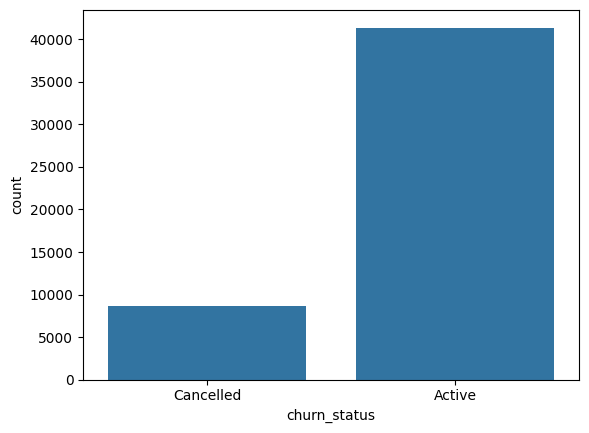

In [26]:
sns.countplot(x="churn_status", data=df)
plt.show()

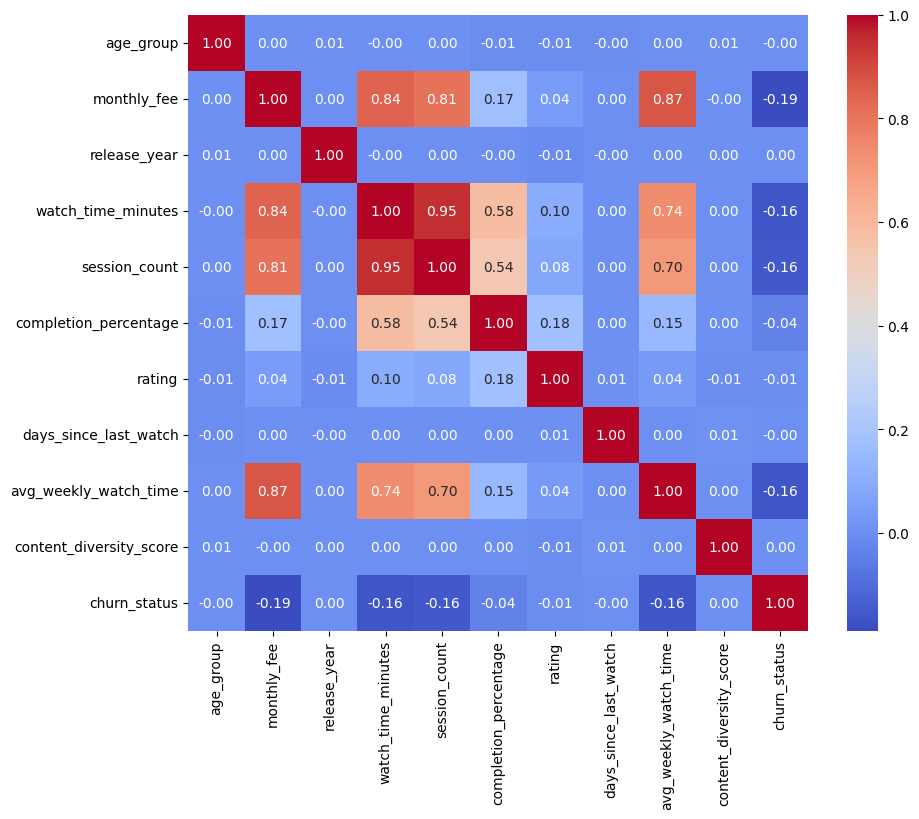

In [27]:
# encode churn_status
df["churn_status"] = df["churn_status"].map({
    "Active": 0,
    "Cancelled": 1
})

# chọn cột numerical
cols = [
    "age_group",
    "monthly_fee",
    "release_year",
    "watch_time_minutes",
    "session_count",
    "completion_percentage",
    "rating",
    "days_since_last_watch",
    "avg_weekly_watch_time",
    "content_diversity_score",
    "churn_status"
]

corr = df[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

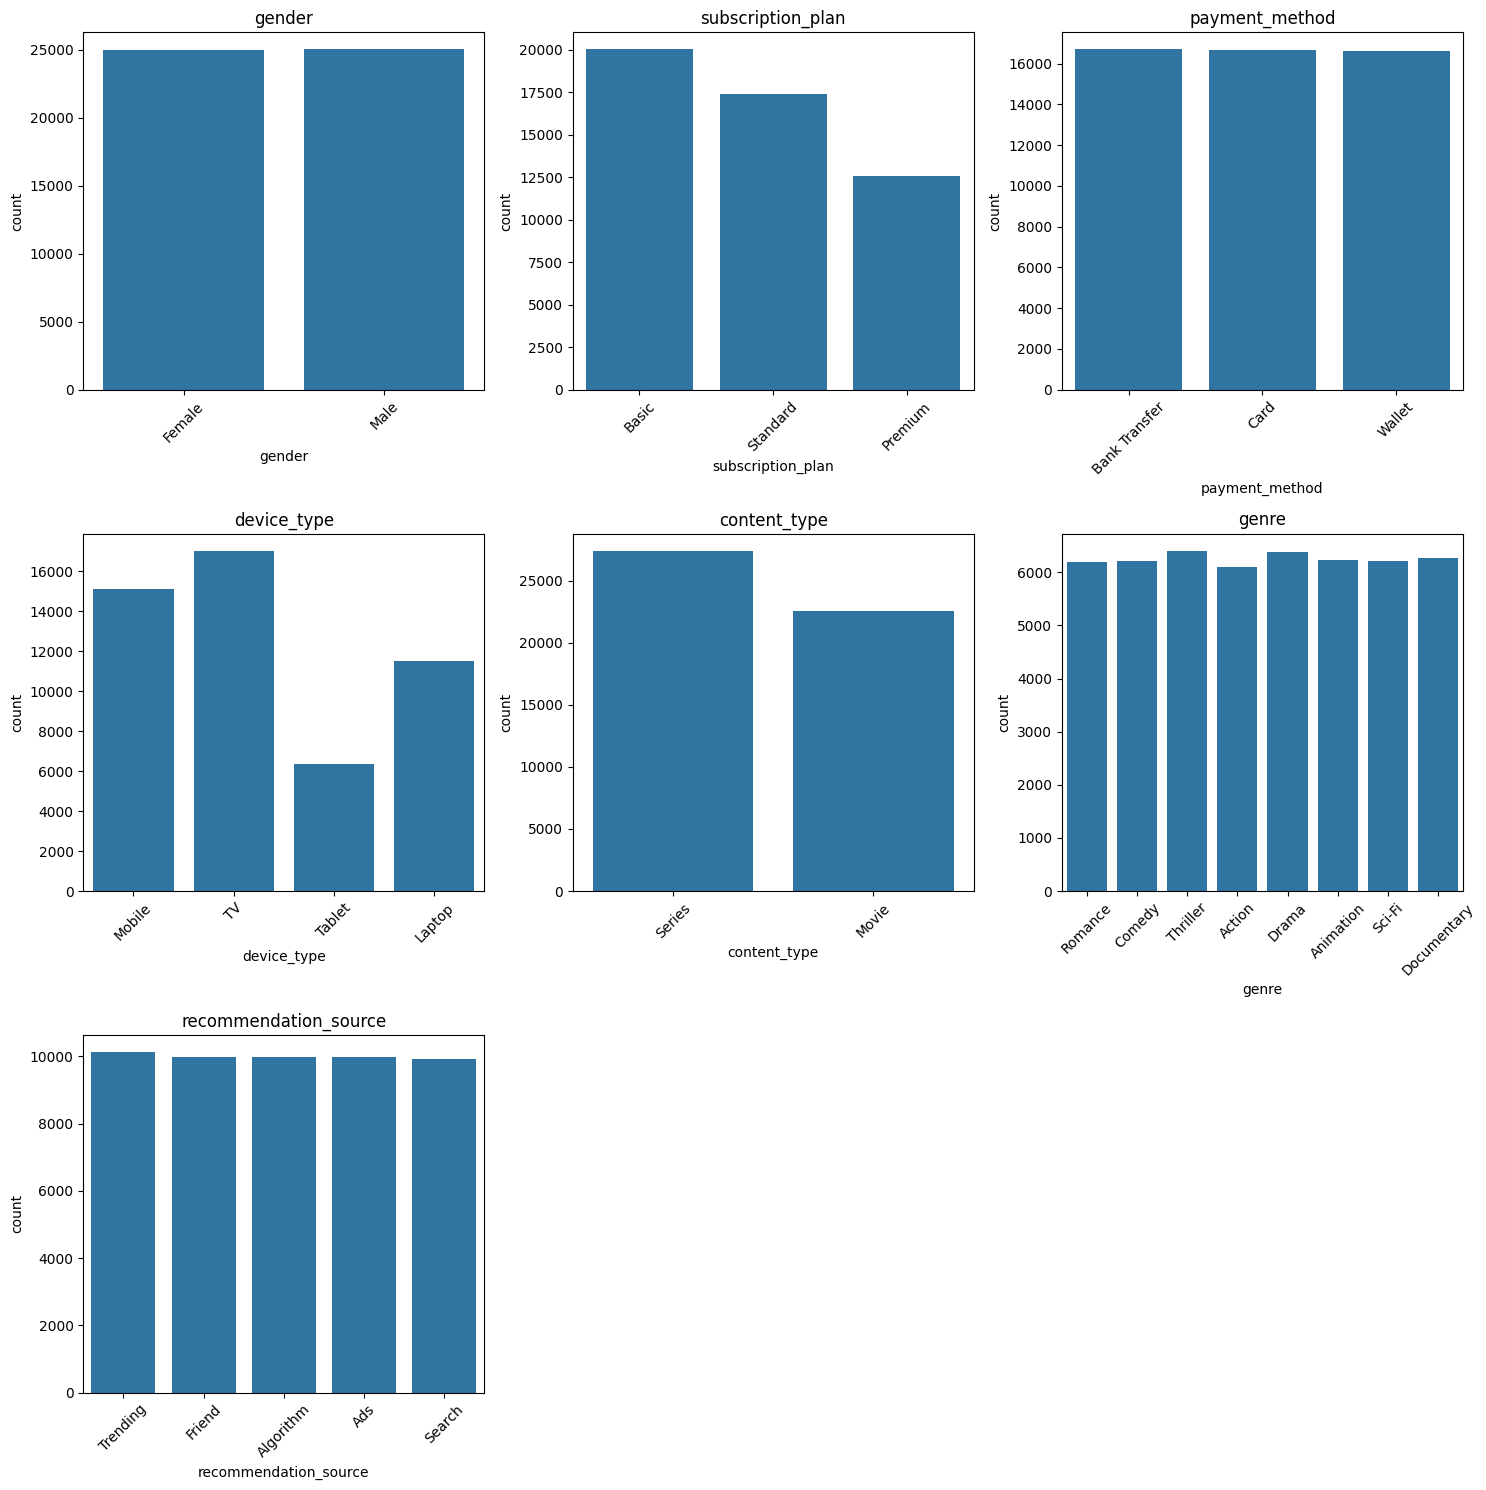

In [28]:

import math

cat_cols = [
    "gender",
    "subscription_plan",
    "payment_method",
    "device_type",
    "content_type",
    "genre",
    "recommendation_source"
]

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# xóa subplot thừa
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

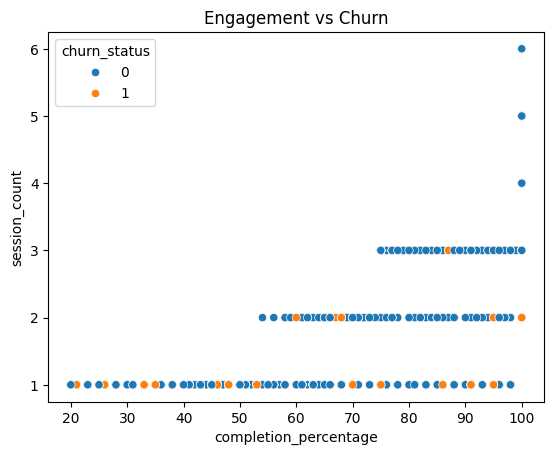

In [31]:
sns.scatterplot(
    x="completion_percentage",
    y="session_count",
    hue="churn_status",
    data=df
)
plt.title("Engagement vs Churn")
plt.show()

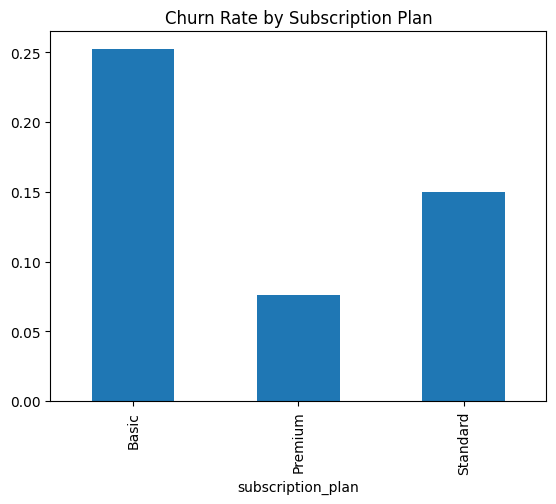

In [30]:
plan_churn = df.groupby("subscription_plan")["churn_status"].mean()

plan_churn.plot(kind="bar")
plt.title("Churn Rate by Subscription Plan")
plt.show()